# Spatial aggregation

Aggregate raster or vector data.

If a raster, aggregates to create a new raster with a lower resolution (larger cells), with the values for the resulting cells is computed with a user-specified function.

If a vector, aggregates ("dissolve") to either combine all geometries into one geometry, or combine the geometries that have the same value for the variable(s) specified with argument `by`.

## Settings

In [29]:
# Load packages
suppressPackageStartupMessages({
  library(terra)
})

# Parameters
param_factor <- 2
param_function <- "mean" # or: "max", "min", "median", "sum", "modal", "any", "all", "prod", "which.min", "which.max", "table", "sd" 
param_group <- "ID_1"
param_out <- tempdir()

# Paths for examples
in_raster <- system.file("ex/elev.tif", package = "terra")
in_vector <- system.file("ex/lux.shp", package = "terra")

## Aggregate raster

In [38]:
# GSTB aggregate raster
# NaaVRE:
#  cell:
#   inputs:
#    - in_raster: String
#   params:
#    - param_factor: Integer
#    - param_function: String
#    - param_out: String
#   outputs:
#    - out: String
#   dependencies:
#    - name: terra
# ...

# File path to be aggregated
x <- rast(in_raster)

# Aggregate raster
aggregate(x         = x,
          fact      = param_factor,
          fun       = param_function,
          filename  = paste0(param_out, "/aggregated_raster.tif"),
          overwrite = TRUE,
          count     = TRUE)

# Output
out <- list.files(path = param_out,
                  pattern = "aggregated_raster.tif",
                  full.names = TRUE)

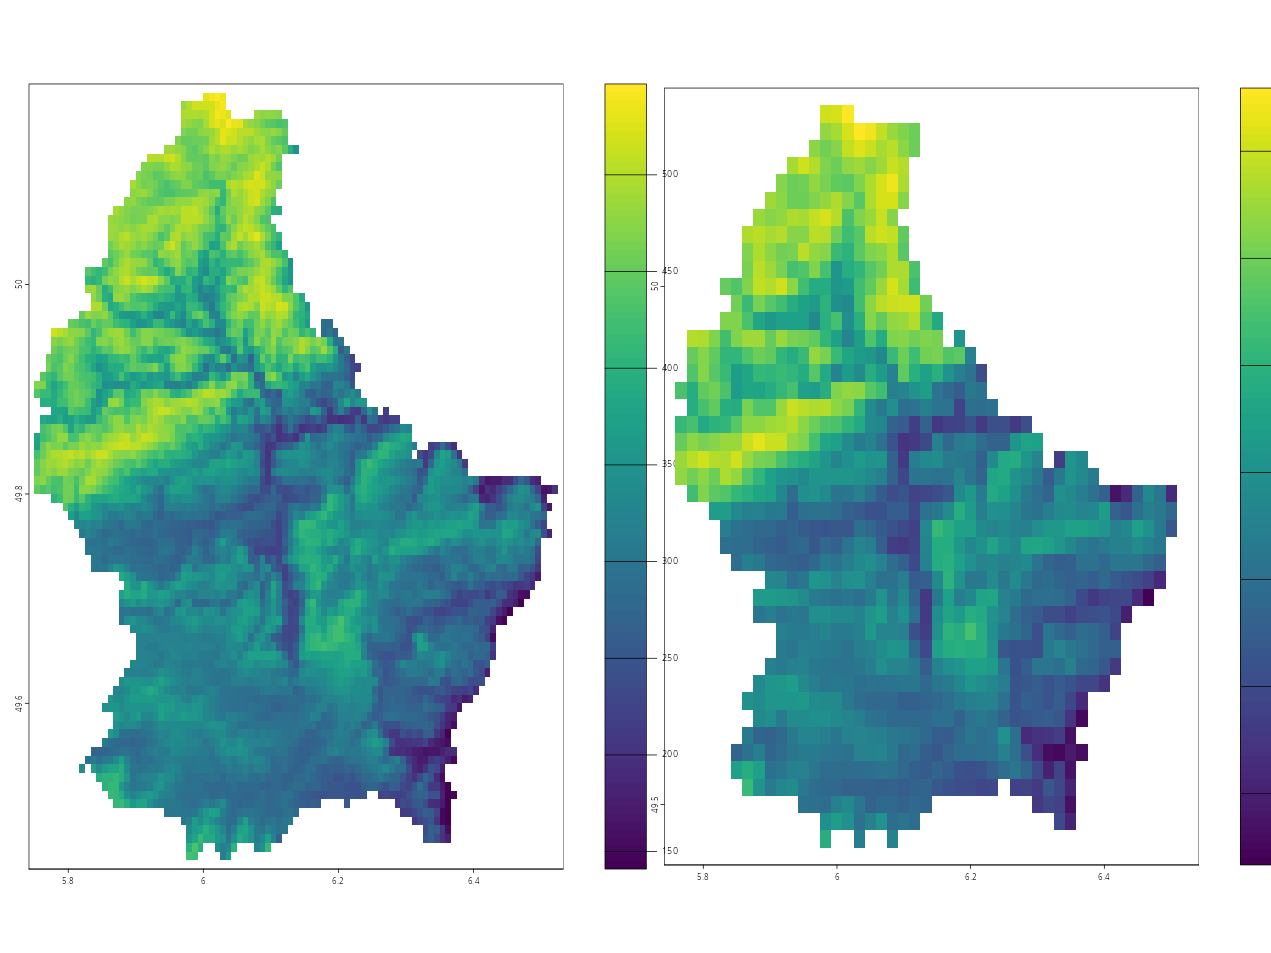

In [39]:
par(mfrow = c(1, 2))
plot(x)
plot(rast(out))
par(mfrow = c(1, 1))

## Aggregate vector

In [40]:
# GSTB aggregate vector
# NaaVRE:
#  cell:
#   inputs:
#    - in_vector: String
#   params:
#    - param_group: String
#    - param_function: String
#    - param_out: String
#   outputs:
#    - out: String
#   dependencies:
#    - name: terra
# ...

# File path to be aggregated
x <- vect(in_vector)

# Aggregate vector
v <- aggregate(x         = x,
               by        = param_group,
               dissolve  = TRUE, 
               fun       = param_function,
               count     = TRUE)
      
# Save to file
writeVector(x         = v,
            filename  = paste0(param_out, "/aggregated_vector.gpkg"),
            overwrite = TRUE)

# Output
out <- list.files(path = param_out,
                  pattern = "aggregated_vector.gpkg",
                  full.names = TRUE)

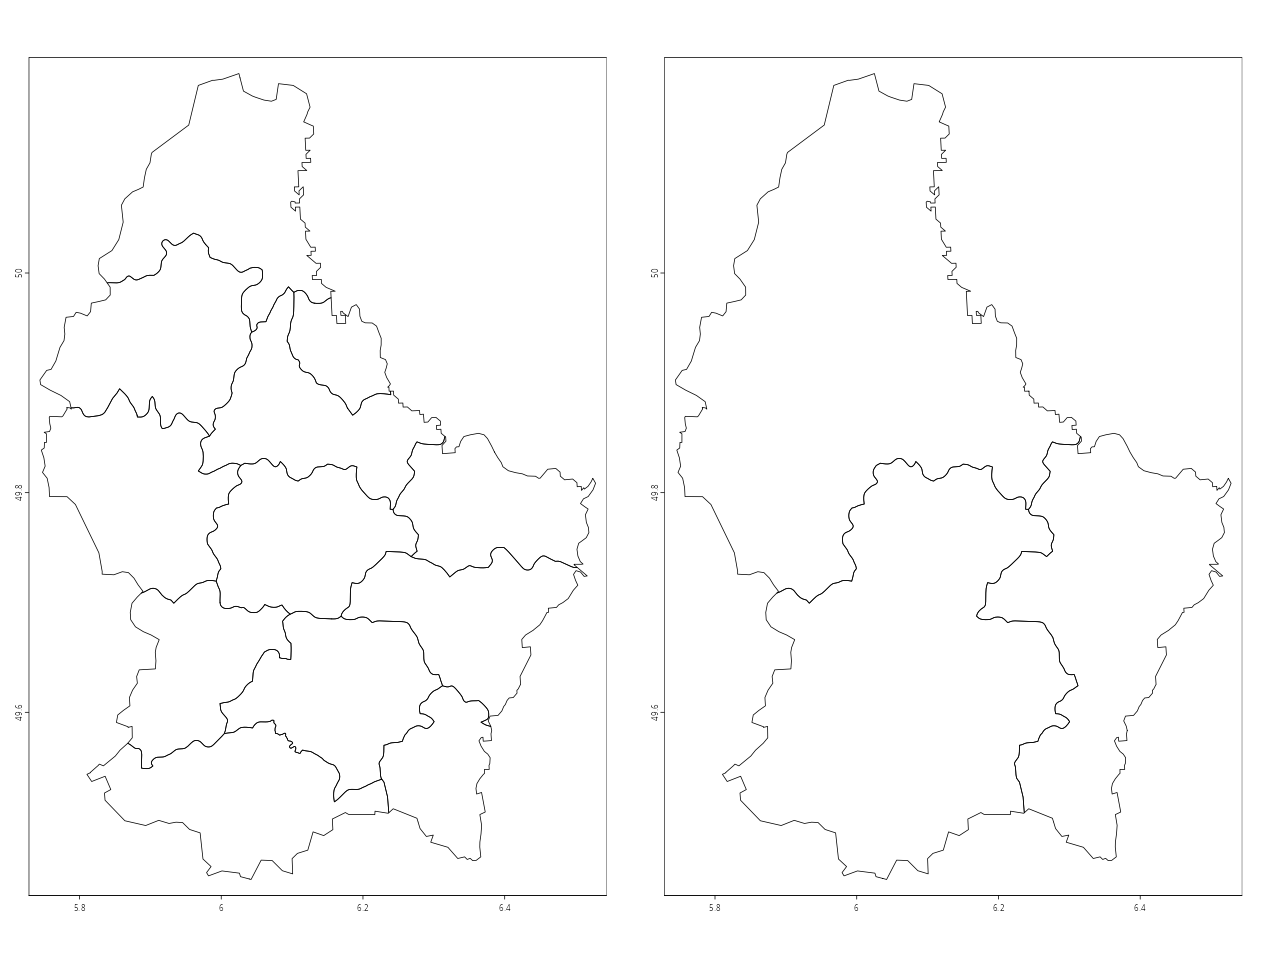

In [41]:
par(mfrow = c(1, 2))
plot(x)
plot(vect(out))
par(mfrow = c(1, 1))